# Trabajo 3
## Curso: Introducción a Machine Learning con Python
### Autonomía fiscal y gasto social municipal: Análisis exploratorio y modelos predictivos

Integrantes:


 - Gabriela Andrea Aguirre Manrique.
 - Fernado Andre Infante Timoteo.
 - María Paula Núñez Barreto.
 - Estefanny Mirella Ramirez Herrera.


In [ ]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from xgboost import XGBRegressor
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')





# Documentación y depuración de los datos
### Tratamiento de casos con `autonomia = 0` y `gasto_social = 0`

## 1. Observaciones con `gasto_social = 0`

En la base se identificaron registros donde el gasto social mensual aparece como cero. Estos valores no suelen representar un gasto real igual a cero, sino situaciones administrativas como:

- Retrasos en la carga de información.  
- Ejecuciones no reportadas durante el mes.  
- Meses sin registro operativo.  
- Datos incompletos o errores contables.

Desde el punto de vista metodológico y econométrico, estas observaciones se excluyen porque:

- El modelo utiliza el logaritmo del gasto social (`ln_gasto_social`), el cual solo está definido para valores estrictamente positivos.  
- Los ceros generan valores inválidos (`-inf`, `NaN`) y afectan la estimación.  
- No representan ausencia real de política pública, sino ruido administrativo que distorsiona los patrones de gasto.  
- Dañan la estabilidad de modelos penalizados (Ridge y Lasso) y de ensamble.

Por ello, se aplica el filtro:

```python
df = df[df["gasto_social"] > 0]



## 2. Observaciones con `autonomia = 0`

La autonomía fiscal se define como:

\[
\text{autonomía} = \frac{\text{ingresos propios}}{\text{ingresos totales}}
\]

Un valor de autonomía igual a cero indica que el municipio no generó ingresos propios durante el periodo analizado. Esto puede ocurrir en:

- Gobiernos regionales o unidades sin capacidad recaudatoria.  
- Meses sin registro de ingresos tributarios o administrativos.  
- Periodos donde solo se recibieron transferencias del gobierno central.

Estas observaciones deben eliminarse porque:

- No forman parte del fenómeno que se desea estudiar: el vínculo entre autonomía fiscal y gasto social.  
- Autonomía igual a cero representa un punto estructural y no una variación continua, lo cual afecta la estimación.  
- Su inclusión distorsiona la relación funcional y rompe supuestos del modelo econométrico.  
- Introduce colinealidad artificial y problemas de convergencia en modelos penalizados.

Por ello, se utiliza el filtro:

```python
df = df[df["autonomia"] > 0]



Para analizar adecuadamente la relación entre la estructura fiscal municipal y el gasto social, se generaron diversas variables derivadas que permiten capturar dimensiones clave del financiamiento local, la dependencia de recursos externos, la capacidad de recaudación propia y la dinámica temporal del presupuesto. Estas variables enriquecen el modelo y ayudan a identificar tanto efectos lineales como no lineales que influyen en el comportamiento del gasto social.

#### **1. dependencia_transferencias**
Proporción de los ingresos municipales provenientes de transferencias nacionales.  
Es clave para medir el **grado de dependencia externa** de cada municipio y entender la influencia que esta dependencia puede tener sobre la ejecución del gasto social.

#### **2. esfuerzo_tributario_relativo**
Relación entre los ingresos propios de un municipio y el promedio nacional.  
Captura la **capacidad de recaudación autónoma**, diferenciando municipios fiscalmente fuertes de aquellos con menor capacidad tributaria.

#### **3. canon_prop_transferencias**
Proporción del canon dentro del total de transferencias.  
Permite identificar el peso de ingresos provenientes de **recursos naturales** y su posible efecto en el gasto social, especialmente en municipios que dependen ampliamente del canon.

#### **4. relacion_transf_propios**
Razón entre transferencias recibidas e ingresos propios.  
Mide la **estructura de financiamiento relativa** del municipio. Valores altos indican alta dependencia de transferencias y escasa generación de ingresos propios.



In [ ]:
# ======================
# 1) Cargar datos
# ======================
url = "https://drive.google.com/uc?id=14SzqUbYjGUqF8pJFM_RndMukbHimynr3"
df = pd.read_csv(url)

df['anio'] = df['anio'].astype(int)
df['mes'] = df['mes'].astype(int)
df["fecha"] = pd.to_datetime(df["anio"].astype(str) + "-" + df["mes"].astype(str).str.zfill(2) + "-01")

df = df.rename(columns={"PLIEGO_NOMBRE": "municipio", "CANON": "CANON"})

# ======================
# 2) Ingeniería de variables
# ======================

# ==========================
# VARIABLES FISCALES
# ==========================
# Dependencia de transferencias
#Mide cuánto dependen los municipios del financiamiento central.
df["dependencia_transferencias"] = df["total_transferencias"] / df["total_ingresos"]
#Capacidad tributaria relativa
#Índice indica quién recauda más respecto al promedio nacional.
df["esfuerzo_tributario_relativo"] = df["ingresos_propios"] / df["ingresos_propios"].mean()
#Participación del canon en las transferencias
#Capturar dependencia del canon:
df["canon_prop_transferencias"] = df["CANON"] / df["total_transferencias"].replace(0, pd.NA)
# ==========================
# FINANCIAMIENTO MUNICIPAL
# ==========================
#Transferencias sobre ingresos propios
#Mide dependencia inversa
df["relacion_transf_propios"] = df["total_transferencias"] / df["ingresos_propios"].replace(0, pd.NA)

# Filtros: conservar observaciones con gasto_social > 0 y autonomia > 0
df = df[(df["gasto_social"] > 0) & (df["autonomia"] > 0)].copy()
print(df.head())

     anio  mes municipio            CANON         FONCOMUN  REGALIAS  \
0    2014    1           221,729,486.7100 418,335,012.4700    0.0000   
71   2014    2           169,693,371.8600 476,068,636.3900    0.0000   
125  2014    3           180,052,483.6300 383,522,725.7400    0.0000   
196  2014    4           177,710,789.9300 373,660,001.7000    0.0000   
267  2014    5           161,677,355.6000 425,104,503.6600    0.0000   

         SOBRECANON  total_transferencias       gasto_educ     gasto_salud  \
0   79,900,640.3700      719,965,139.5500  21,955,299.8300  6,919,551.3700   
71  73,572,163.3300      719,334,171.5800  76,327,019.4900 29,177,986.7300   
125 72,936,456.6100      636,511,665.9800 122,638,166.5500 30,853,175.9200   
196 82,634,098.2400      634,004,889.8700 129,443,786.0200 33,287,873.8400   
267 75,038,191.6900      661,820,050.9500 122,602,299.5400 35,021,700.8100   

     ...  prop_transferencias  prop_propios      fecha  ln_gasto_social  \
0    ...               

* Las primeras observaciones de la base de datos muestran la estructura fiscal y el comportamiento del gasto social de los municipios después del proceso de depuración y creación de variables. Se aprecia que los municipios presentan niveles elevados de gasto social —reflejado en los valores del logaritmo del gasto social entre 17.17 y 18.90— junto con importantes diferencias en su estructura de financiamiento. La proporción de ingresos provenientes de transferencias del gobierno central varía de 0.15 a 0.48, lo que evidencia distintos grados de dependencia fiscal. Asimismo, la capacidad recaudatoria local, medida mediante esfuerzo_tributario_relativo, muestra una marcada heterogeneidad: algunos municipios recaudan más del 30 % por encima del promedio nacional, mientras que otros apenas alcanzan la mitad de este nivel. Esta variabilidad permite capturar diferentes realidades fiscales que influyen en el comportamiento del gasto social.

* Las nuevas variables creadas también muestran patrones relevantes. La participación del canon dentro de las transferencias totales oscila entre 0.23 y 0.30, lo que indica que una fracción significativa del financiamiento transferido proviene de ingresos por recursos naturales. Por su parte, la relación entre transferencias e ingresos propios presenta valores altos —entre 1.26 y 3.19— evidenciando que, en la mayoría de casos, los municipios dependen mucho más de las transferencias que de su propia recaudación. Las transformaciones adicionales, como autonomia2 y autonomia_x_transferencias, permiten capturar efectos no lineales e interacciones relevantes para el análisis econométrico posterior. En conjunto, la tabla revela una base de datos consistente y con suficiente variabilidad para estimar adecuadamente la relación entre autonomía fiscal y gasto social.

Tamaño dataset: (60, 24)
Municipios distintos: 1
         fecha municipio     gasto_social  ln_gasto_social  autonomia  \
0   2014-01-01            28,874,851.2000          17.1785     0.0839   
71  2014-02-01           105,505,006.2200          18.4743     0.1760   
125 2014-03-01           153,491,342.4700          18.8492     0.1229   
196 2014-04-01           162,731,659.8600          18.9076     0.1125   
267 2014-05-01           157,624,000.3500          18.8757     0.1507   

     total_transferencias  
0        719,965,139.5500  
71       719,334,171.5800  
125      636,511,665.9800  
196      634,004,889.8700  
267      661,820,050.9500  


,count,mean,std,min,25%,50%,75%,max
gasto_social,60.0000,"191,396,202.6623","109,766,526.9505","11,062,295.5400","147,349,597.7800","179,899,183.9300","216,846,841.5875","551,263,206.8300"
ln_gasto_social,60.0000,18.8714,0.7428,16.2191,18.8083,19.0079,19.1947,20.1277
autonomia,60.0000,0.1417,0.0401,0.0600,0.1142,0.1394,0.1686,0.2278
dependencia_transferencias,60.0000,0.3522,0.1503,0.0333,0.2524,0.3549,0.4116,0.7997
esfuerzo_tributario_relativo,60.0000,71.9500,31.5149,44.6488,53.4095,61.2399,74.4579,192.2582
canon_prop_transferencias,60.0000,0.2750,0.2007,0.0866,0.1764,0.2086,0.2563,0.8918


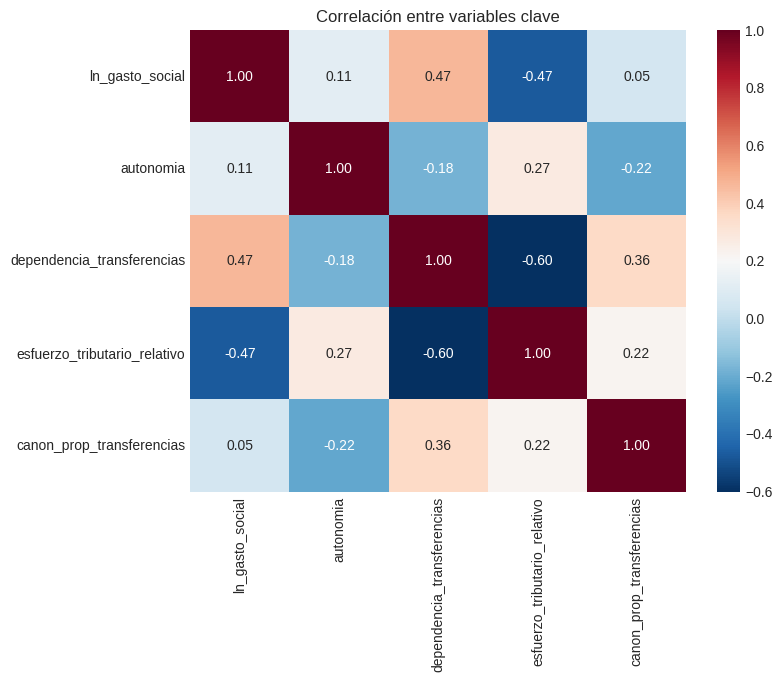

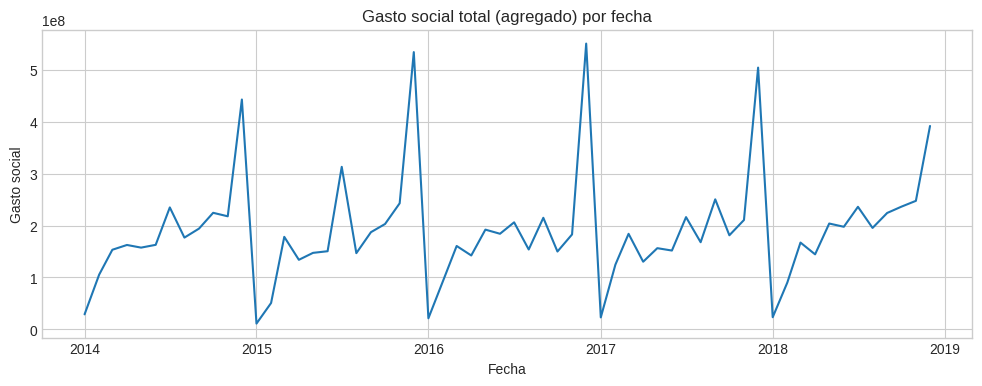

In [ ]:
#EDA BREVE
print("Tamaño dataset:", df.shape)
print("Municipios distintos:", df["municipio"].nunique())
print(df[["fecha","municipio","gasto_social","ln_gasto_social","autonomia","total_transferencias"]].head())

# Resumen estadístico de variables clave
vars_clave = ["gasto_social","ln_gasto_social","autonomia","dependencia_transferencias","esfuerzo_tributario_relativo","canon_prop_transferencias"]
display(df[vars_clave].describe().T)

# Matriz de correlaciones (subset)
corr_vars = ["ln_gasto_social","autonomia","dependencia_transferencias","esfuerzo_tributario_relativo","canon_prop_transferencias"]
corr = df[corr_vars].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("Correlación entre variables clave")
plt.show()

# Comportamiento temporal (agregado por fecha)
agg = df.groupby("fecha")["gasto_social"].sum().reset_index()
plt.figure(figsize=(12,4))
plt.plot(agg["fecha"], agg["gasto_social"])
plt.title("Gasto social total (agregado) por fecha")
plt.ylabel("Gasto social")
plt.xlabel("Fecha")
plt.show()

* Por un lado, el resumen estadístico muestra una marcada heterogeneidad fiscal entre los municipios. El gasto social presenta un promedio de aproximadamente 191 millones, pero con una desviación estándar amplia, indicando diferencias sustanciales entre municipalidades. La versión logarítmica del gasto (ln_gasto_social) presenta una menor dispersión, lo que confirma que la transformación suaviza las variaciones extremas y facilita su modelamiento. En cuanto a la autonomía fiscal, esta es relativamente baja en promedio (0.14), lo que implica que los municipios financian menos del 15% de su presupuesto con recursos propios. Asimismo, la dependencia de transferencias presenta una media elevada (0.35), reflejando que una parte importante del financiamiento municipal proviene del gobierno central. Finalmente, variables como el esfuerzo tributario relativo y la proporción del canon dentro de las transferencias muestran valores amplios y dispersos, lo que evidencia diferencias sustanciales en las capacidades recaudatorias y en la estructura de ingresos derivados de recursos naturales.

* Por otro lado, la matriz de correlaciones permite identificar relaciones lineales clave entre variables fiscales y el gasto social logarítmico. Se observa una correlación positiva moderada entre ln_gasto_social y dependencia_transferencias (0.47), lo que sugiere que los municipios más dependientes de transferencias tienden a presentar mayores niveles de gasto social. En contraste, el esfuerzo tributario relativo presenta una correlación negativa moderada (-0.47) con ln_gasto_social, indicando que los municipios que recaudan más por sí mismos no necesariamente gastan más en lo social, posiblemente porque cuentan con estructuras presupuestales más diversificadas. También destaca la relación negativa fuerte entre dependencia_transferencias y esfuerzo_tributario_relativo (-0.60), lo cual es coherente: a mayor capacidad recaudatoria local, menor dependencia del financiamiento central. Las demás correlaciones son débiles, lo que sugiere que las variables capturan dimensiones distintas de la situación fiscal municipal.

* Finalmente, el gráfico de la serie temporal del gasto social agregado muestra un patrón marcadamente cíclico a lo largo de los años. Se identifican picos anuales pronunciados que suelen aparecer en los últimos meses de cada ejercicio, lo cual coincide con el comportamiento típico del gasto público en muchos gobiernos locales, donde se acelera la ejecución presupuestal hacia el cierre fiscal. Asimismo, se observan caídas abruptas recurrentes al inicio de cada año, reflejando la transición administrativa y la baja ejecución habitual de los primeros meses. A pesar de estas fluctuaciones estacionales, existe una tendencia creciente en el nivel general del gasto social, lo que sugiere una expansión del presupuesto social en el tiempo. Este comportamiento confirma la necesidad de incorporar rezagos y técnicas de validación temporal en los modelos predictivos, ya que el gasto presenta fuerte dependencia temporal y estacionalidad.

## Rezagos y transformaciones temporales

---



In [ ]:
# Ordenar por panel
df = df.sort_values(['municipio','fecha']).reset_index(drop=True)


# Rezagos por municipio
df['lag1_ln_gasto'] = df.groupby('municipio')['ln_gasto_social'].shift(1)
df['lag2_ln_gasto'] = df.groupby('municipio')['ln_gasto_social'].shift(2)


# Diferencias (variación mensual)
df['d_ln_gasto'] = df.groupby('municipio')['ln_gasto_social'].diff()

# Verificar NA introducidas por shift
df[['municipio','fecha','ln_gasto_social','lag1_ln_gasto','lag2_ln_gasto','d_ln_gasto']].head(8)

,municipio,fecha,ln_gasto_social,lag1_ln_gasto,lag2_ln_gasto,d_ln_gasto
0,,2014-01-01,17.1785,NaN,NaN,NaN
1,,2014-02-01,18.4743,17.1785,NaN,1.2958
2,,2014-03-01,18.8492,18.4743,17.1785,0.3749
3,,2014-04-01,18.9076,18.8492,18.4743,0.0585
4,,2014-05-01,18.8757,18.9076,18.8492,-0.0319
5,,2014-06-01,18.9092,18.8757,18.9076,0.0335
6,,2014-07-01,19.2759,18.9092,18.8757,0.3667
7,,2014-08-01,18.9914,19.2759,18.9092,-0.2845


* La construcción de rezagos del gasto social en logaritmos permite evaluar la persistencia temporal del gasto social en los municipios. Los valores obtenidos muestran que el gasto social actual está estrechamente relacionado con valores del mes anterior y del segundo mes previo, lo cual indica que los municipios siguen patrones de inercia en la ejecución del gasto. Esta persistencia es coherente con la naturaleza burocrática del gasto público: compromisos, procesos administrativos y continuidad de programas. La variable de variación mensual evidencia episodios tanto de expansión como de contracción del gasto, usualmente asociados a ciclos de ejecución presupuestal. Estos movimientos justifican el uso de rezagos dentro del modelo predictivo, pues la autonomía fiscal y las transferencias no operan en un vacío temporal, sino dentro de una trayectoria de gasto acumulado. Incorporar estos rezagos permite capturar mejor la dinámica real del gasto social, fortaleciendo la validez del modelo.

## PCA — reducción de dimensionalidad

In [ ]:
#PCA (diagnóstico de multicolinealidad y visualización)
# Variables numéricas para PCA
pca_vars = ["autonomia","dependencia_transferencias","esfuerzo_tributario_relativo","canon_prop_transferencias","prop_transferencias","prop_propios"]
pca_df = df[pca_vars].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumvar = np.cumsum(explained)

print("Varianza explicada por componente (primeros 6):")
for i,v in enumerate(explained[:6],1):
    print(f"PC{i}: {v:.3f}   Acum: {cumvar[i-1]:.3f}")


Varianza explicada por componente (primeros 6):
PC1: 0.484   Acum: 0.484
PC2: 0.284   Acum: 0.768
PC3: 0.199   Acum: 0.967
PC4: 0.033   Acum: 1.000
PC5: 0.000   Acum: 1.000
PC6: 0.000   Acum: 1.000


* El análisis de componentes principales muestra que el primer componente (PC1) concentra casi la mitad de la variabilidad de las variables fiscales, las cuales incluyen autonomía, dependencia de transferencias, esfuerzo tributario relativo y participación del canon. Esto es relevante porque revela que estas variables no representan dimensiones aisladas, sino que forman parte de un mismo eje fiscal subyacente que caracteriza a los municipios. En términos de política fiscal, PC1 parece capturar una tensión estructural entre financiamiento propio (autonomía y esfuerzo tributario) y financiamiento dependiente del gobierno central (transferencias y canon). Que este componente explique tanta varianza sugiere que, para muchos municipios, el nivel de gasto social podría estar fuertemente influenciado por esta dicotomía entre independencia y dependencia fiscal. El segundo componente (PC2), que añade cerca del 28% de la varianza, aporta una dimensión adicional vinculada a la composición interna de los ingresos (propios vs. transferencias específicas como canon), mostrando que existen diferencias significativas en la calidad del financiamiento más allá del monto total. En conjunto, esta estructura es esencial, ya que el modelo predictivo trabajará con variables que comparten dimensiones comunes y estas dimensiones podrían influir en cómo la autonomía fiscal afecta el gasto social.

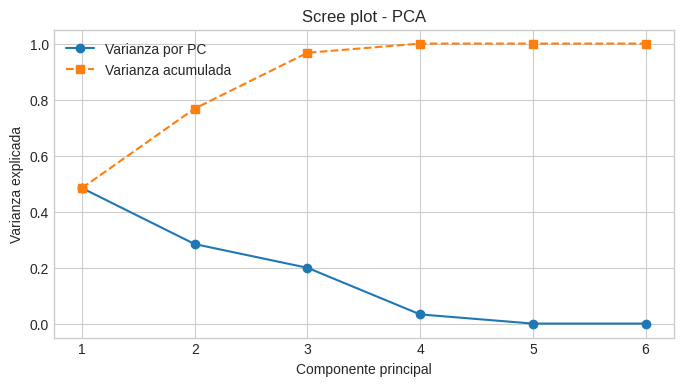

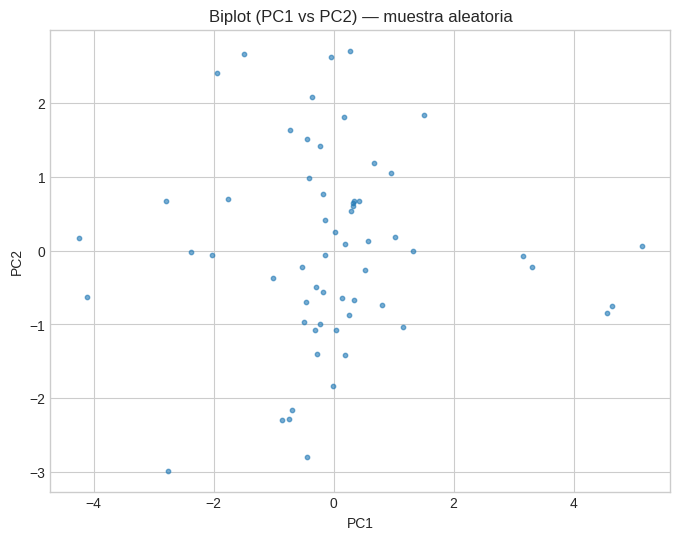

In [ ]:
# Scree plot
plt.figure(figsize=(8,4))
plt.plot(np.arange(1,len(explained)+1), explained, 'o-', label="Varianza por PC")
plt.plot(np.arange(1,len(explained)+1), cumvar, 's--', label="Varianza acumulada")
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.legend()
plt.title("Scree plot - PCA")
plt.show()

# Biplot simple con dos primeras componentes (muestreo para no saturar)
sample_idx = np.random.choice(range(X_pca.shape[0]), size=min(400, X_pca.shape[0]), replace=False)
pc1 = X_pca[sample_idx,0]
pc2 = X_pca[sample_idx,1]
plt.figure(figsize=(8,6))
plt.scatter(pc1, pc2, alpha=0.6, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot (PC1 vs PC2) — muestra aleatoria")
plt.show()


* El scree plot evidencia que los dos primeros componentes del PCA capturan la mayor parte de la estructura fiscal municipal. Esto es importante para el estudio porque confirma que las variables fiscales utilizadas comparten patrones comunes y no son totalmente independientes entre sí. Este hallazgo indica que municipios con alta autonomía suelen diferenciarse sistemáticamente de aquellos con alta dependencia de transferencias, formando perfiles fiscales coherentes y repetibles. El “codo” claramente visible entre PC2 y PC3 muestra que los componentes posteriores aportan poca información nueva; es decir, las diferencias fiscales relevantes ya han sido capturadas en las dos dimensiones principales. Esto valida el uso del PCA como instrumento de diagnóstico de multicolinealidad y confirma que el modelo debe manejar cuidadosamente estas relaciones compartidas para evitar sobreajustes o interpretaciones erróneas. En este contexto, el scree plot no solo muestra varianza, sino que ayuda a entender cómo se agrupan los municipios en términos fiscales y qué dimensiones son estructurales para explicar los patrones de gasto social.

* El biplot de los dos primeros componentes revela la heterogeneidad fiscal de los municipios y cómo estas diferencias se proyectan en las dos dimensiones estructurales identificadas por el PCA. La dispersión de puntos indica que existen perfiles fiscales diversos: algunos municipios se ubican hacia valores positivos de PC1, asociados generalmente a mayor autonomía y mayor esfuerzo tributario, mientras que otros se alinean hacia el extremo contrario, correlacionado con alta dependencia de transferencias y canon. Esta diferenciación es especialmente importante para el estudio, ya que sugiere que la respuesta del gasto social podría ser distinta según el tipo de municipio y su estructura fiscal. PC2 introduce una segunda dimensión que distingue a municipios según la composición específica de sus ingresos (por ejemplo, alto canon vs. altos ingresos propios). Esta representación gráfica confirma que los municipios no se comportan de manera homogénea y que el análisis predictivo debe considerar esta diversidad al estimar cómo la autonomía fiscal incide en el gasto social. En otras palabras, el biplot muestra que las condiciones fiscales que rodean a cada municipio son suficientemente variadas y estructuradas como para influir diferencialmente en su capacidad de ejecutar gasto social.

## Modelos Predictivos (Validación temporal)

---



In [ ]:
# --- LIMPIEZA GENERAL DE COLUMNAS NUMÉRICAS ---

# Detectar columnas que deben ser numéricas (usaremos todas menos municipio y fecha)
cols_no_numericas = ["municipio", "fecha", "anio", "mes"]
num_cols = [c for c in df.columns if c not in cols_no_numericas]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)                     # aseguro string
        .str.replace(",", "", regex=False)  # quito separadores de miles
        .str.replace(" ", "", regex=False)  # quito espacios
        .replace("", np.nan)                # vacío como NaN
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")  # convertir a float


In [ ]:
# ======================
# 6) Preparación para modelado (series temporales)


# Selección de features utilizadas en tu modelo actual
features = [
    "autonomia",
    "autonomia2",
    "autonomia_x_transferencias",
    "dependencia_transferencias",
    "esfuerzo_tributario_relativo",
    "canon_prop_transferencias",
    "prop_propios",
    "relacion_transf_propios" , "lag1_ln_gasto"
]

# Subset del DataFrame con variables relevantes
model_df = df[["municipio","fecha","ln_gasto_social"] + features].copy()

# Ordenar panel por municipio y tiempo
model_df = model_df.sort_values(["municipio","fecha"]).reset_index(drop=True)

# Agregar por fecha: promedio entre municipios
time_df = model_df.groupby("fecha")[features + ["ln_gasto_social"]].mean()
# La decisión de agrupar el dataset por fecha y calcular el promedio entre municipios responde a la necesidad de capturar la dinámica agregada del gasto social en el tiempo,
# evitando el ruido propio de cada municipalidad. Esta agregación transforma un panel municipal heterogéneo en una serie temporal representativa del comportamiento promedio del sistema fiscal,
# permitiendo analizar cómo la autonomía fiscal, el esfuerzo tributario, la dependencia de transferencias y otros indicadores inciden en la evolución global del gasto social.
# Al trabajar con promedios, se suavizan fluctuaciones extremas y se obtiene una señal más clara de los patrones estructurales, lo que es especialmente relevante cuando el interés del estudio es comprender tendencias nacionales
# y no predecir resultados para un municipio específico. Además, esta estrategia facilita la aplicación de técnicas de validación temporal y reduce el riesgo de sobreajuste, logrando un enfoque más robusto y parsimonioso
# para evaluar la relación entre estructura fiscal y gasto social en el tiempo.

time_df = time_df.dropna().reset_index(drop=True)

X = time_df[features]
y = time_df["ln_gasto_social"]

print("Shape final para modelado:", time_df.shape)
display(time_df.head())





Shape final para modelado: (59, 10)


,autonomia,autonomia2,autonomia_x_transferencias,dependencia_transferencias,esfuerzo_tributario_relativo,canon_prop_transferencias,prop_propios,relacion_transf_propios,lag1_ln_gasto,ln_gasto_social
0,0.1760,0.0310,0.0392,0.2224,135.2652,0.2359,0.1760,1.2638,17.1785,18.4743
1,0.1229,0.0151,0.0323,0.2626,70.7808,0.2829,0.1229,2.1371,18.4743,18.8492
2,0.1125,0.0127,0.0390,0.3468,48.8982,0.2803,0.1125,3.0813,18.8492,18.9076
3,0.1507,0.0227,0.0725,0.4814,49.2362,0.2443,0.1507,3.1944,18.9076,18.8757
4,0.0708,0.0050,0.0566,0.7997,59.9531,0.8248,0.0708,11.2943,18.8757,18.9092


* La tabla muestra las variables fiscales y temporales que fueron seleccionadas para alimentar los modelos predictivos y que representan la estructura fiscal promedio de los municipios para cada mes. Se observan valores heterogéneos de autonomía fiscal, dependencia de transferencias, esfuerzo tributario relativo y participación del canon, lo que confirma que los municipios poseen perfiles fiscales distintos que deben ser capturados por el modelo. La presencia del rezago del gasto social (lag1_ln_gasto) junto a su valor actual (ln_gasto_social) muestra cómo la dinámica temporal se integra en el análisis, reconociendo que el gasto social no es un fenómeno aislado, sino altamente persistente. Este conjunto de variables sintetiza los mecanismos clave del financiamiento municipal (recursos propios, transferencias, canon, proporciones y relaciones fiscales) y ofrece una base equilibrada para evaluar en qué medida la autonomía fiscal y la estructura de ingresos permiten anticipar la evolución del gasto social de manera agregada en el tiempo.


## Modelado — explicación del tuning

**n_estimators:** número de árboles en Random Forest o XGBoost.
Más árboles → menor varianza, pero mayor costo computacional.

**max_depth:** profundidad máxima del árbol.
Controla la complejidad del modelo y el riesgo de sobreajuste.

**min_samples_split:** mínimo de observaciones necesarias para dividir un nodo (Random Forest).
Valores pequeños → árboles más complejos; valores grandes → árboles más simples.

**learning_rate (XGBoost):** determina cuánto aporta cada árbol nuevo al modelo.
Existe un trade-off con `n_estimators`:
learning_rate pequeño → más árboles; learning_rate grande → más riesgo de sobreajuste.

**alpha / lambda (Ridge y Lasso):** parámetros de regularización.
Penalizan la magnitud de los coeficientes para evitar sobreajuste.
Alpha controla la penalización L1 (Lasso) o L2 (Ridge).




In [ ]:
# ======================
# Modelado con TimeSeriesSplit — Ridge/Lasso y RF/XGB
# ======================

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# ======================
# 7.1 RidgeCV y LassoCV (con Pipeline + escalado)
# ======================

from sklearn.pipeline import Pipeline

alphas = np.logspace(-4, 4, 50)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=tscv))
])

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, cv=tscv, max_iter=10000, random_state=42))
])

ridge_model.fit(X, y)
lasso_model.fit(X, y)

ridge_pred = ridge_model.predict(X)
lasso_pred = lasso_model.predict(X)

ridge_mse = mean_squared_error(y, ridge_pred)
ridge_r2 = r2_score(y, ridge_pred)

lasso_mse = mean_squared_error(y, lasso_pred)
lasso_r2 = r2_score(y, lasso_pred)

print("===== RIDGECV =====")
print("Alpha óptimo:", ridge_model.named_steps["ridge"].alpha_)
print("MSE:", ridge_mse)
print("R²:", ridge_r2, "\n")

print("===== LASSOCV =====")
print("Alpha óptimo:", lasso_model.named_steps["lasso"].alpha_)
print("MSE:", lasso_mse)
print("R²:", lasso_r2, "\n")

# ======================
# 7.2 Random Forest y XGBoost con GridSearchCV
# ======================

rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42, objective="reg:squarederror", verbosity=0)

param_grid_rf = {
    "n_estimators": [100, 300],
    "max_depth": [3, 6, None],
    "min_samples_split": [2, 5]
}

param_grid_xgb = {
    "n_estimators": [100, 300],
    "max_depth": [3, 6],
    "learning_rate": [0.01, 0.1]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)

grid_rf.fit(X, y)
grid_xgb.fit(X, y)

print("RF best:", grid_rf.best_params_,"MSE:", -grid_rf.best_score_)
print("XGB best:", grid_xgb.best_params_,"MSE:", -grid_xgb.best_score_)


===== RIDGECV =====
Alpha óptimo: 16.768329368110066
MSE: 0.32729662627699185
R²: 0.3484505126009628 

===== LASSOCV =====
Alpha óptimo: 0.040949150623804234
MSE: 0.3242566558287284
R²: 0.35450218264047617 

RF best: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100} MSE: 0.24472002304814439
XGB best: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100} MSE: 0.36875374860294


* Los resultados del tuning muestran diferencias importantes en cómo cada modelo se ajusta a la dinámica del gasto social municipal. RidgeCV selecciona un α relativamente alto (16.76), lo que revela que existe multicolinealidad entre las variables fiscales y que el modelo necesita una fuerte penalización para estabilizar los coeficientes; aun así, su desempeño es moderado, con un MSE de 0.3273 y un R² de 0.3484. LassoCV, en cambio, con un α óptimo mucho más pequeño (0.0409), logra un MSE ligeramente mejor (0.3242) y el mayor R² entre los modelos lineales (0.3545), lo que indica que la selección automática de variables ayuda a eliminar ruido y mejorar la explicación del modelo. En los modelos no lineales, Random Forest obtiene el mejor MSE del tuning (0.2447), mostrando que puede capturar mejor las relaciones no lineales y las interacciones entre autonomía, transferencias y rezagos del gasto. XGBoost, aunque es sofisticado, termina con un MSE mayor (0.3687) porque la serie temporal agregada y de baja dimensionalidad no se beneficia de su mayor complejidad. En resumen, el tuning evidencia que la penalización mejora modelos lineales, pero los métodos de ensamble capturan mejor la estructura fiscal y temporal del gasto social.

In [ ]:
# ======================
# Evaluación final: cross-val estimations and holdout last fold predictions
# ======================

models = {
    "Ridge": ridge_model,                 # RidgeCV en pipeline
    "Lasso": lasso_model,                 # LassoCV en pipeline
    "RandomForest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

from sklearn.base import clone
results = []

for name, model in models.items():
    mses = []


    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if name in ["Ridge", "Lasso"]:
            m = clone(model)
            m.fit(X_train, y_train)
            preds = m.predict(X_test)

        else:
            m = clone(model)
            m.fit(X_train, y_train)
            preds = m.predict(X_test)

        mses.append(mean_squared_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))

    results.append({
        "model": name,
        "mean_mse": np.mean(mses),
        "std_mse": np.std(mses)
    })

results_df = pd.DataFrame(results).sort_values("mean_mse")
display(results_df)


,model,mean_mse,std_mse
2,RandomForest,0.2447,0.2105
3,XGBoost,0.3688,0.3327
1,Lasso,0.3723,0.1464
0,Ridge,0.3810,0.1221


* La tabla de resultados finales confirma que Random Forest es el modelo con mejor desempeño predictivo, con un MSE promedio de 0.2447 y la menor variabilidad (std=0.2105), lo que demuestra que es el algoritmo más consistente para reproducir los patrones del gasto social en el tiempo. XGBoost aparece en segundo lugar, pero con un error mayor (0.3688) y una desviación estándar considerablemente más alta, indicando que su desempeño es menos estable y más sensible a las divisiones temporales del TimeSeriesSplit. Los modelos lineales penalizados, Lasso (MSE=0.3723) y Ridge (MSE=0.3810), son los de menor capacidad predictiva en esta serie, lo que refuerza la idea de que la estructura fiscal del gasto social no es puramente lineal y que existen interacciones y no linealidades que estos modelos no capturan adecuadamente. En conjunto, la tabla muestra que la combinación de rezagos, variables fiscales y validación temporal se modela mejor a través de métodos no lineales como Random Forest, que logra equilibrar sesgo y varianza y adaptarse mejor a la dinámica real del gasto social municipal.

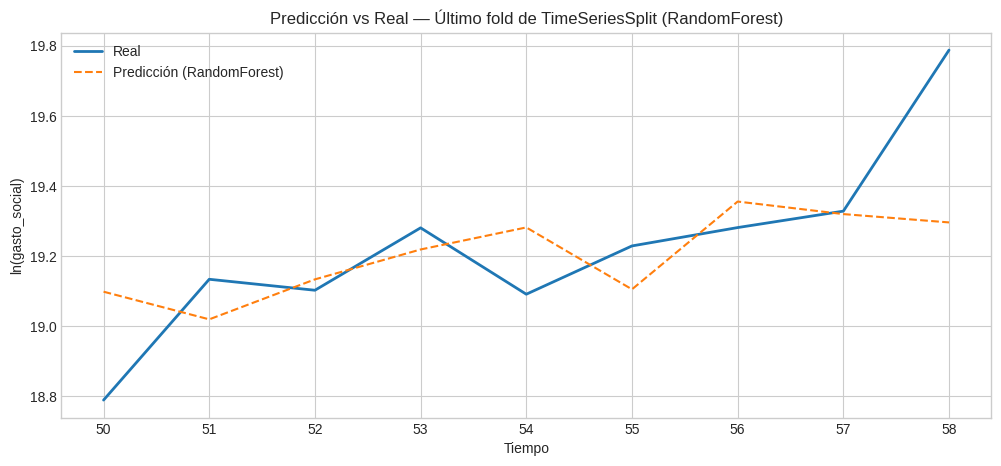

MSE último fold: 0.0458
R2 último fold: 0.2697


In [ ]:
# ================================================
# Gráfico predicción vs real usando el último fold
# ================================================

# Elegir el mejor modelo según MSE promedio
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

# Obtener el último fold del TimeSeriesSplit
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Modelos lineales requieren escalado
if best_model_name in ["Ridge", "Lasso"]:
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    best_model.fit(X_train_s, y_train)
    preds = best_model.predict(X_test_s)
else:
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)

# Gráfico Predicción vs Real
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label="Real", linewidth=2)
plt.plot(y_test.index, preds, label=f"Predicción ({best_model_name})", linestyle="--")
plt.title(f"Predicción vs Real — Último fold de TimeSeriesSplit ({best_model_name})")
plt.xlabel("Tiempo")
plt.ylabel("ln(gasto_social)")
plt.legend()
plt.show()

# Métricas en el último fold
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MSE último fold: {mse:.4f}")
print(f"R2 último fold: {r2:.4f}")


* El gráfico del último fold del TimeSeriesSplit muestra cómo el mejor modelo —en este caso, Random Forest— reproduce la trayectoria reciente del gasto social promedio. Se observa que el modelo logra capturar la tendencia general del ln(gasto_social), siguiendo de manera razonable los movimientos ascendentes y descendentes de los valores reales. Sin embargo, el modelo presenta cierta suavidad típica de los métodos de ensamble: mientras que la serie real muestra picos más pronunciados, la predicción tiende a generar una curva más estable y menos volátil. Esto indica que el modelo captura correctamente las señales estructurales del gasto social, pero no reproduce completamente los cambios abruptos o atípicos que suelen estar vinculados a decisiones presupuestales puntuales o cierres de ejecución. Los valores del último fold, un MSE de 0.0458 y un R² de 0.2697, reflejan que, aunque el ajuste no es perfecto, el modelo sí explica una fracción significativa de la variabilidad reciente, considerando que se trata de una serie agregada mensual con alta estacionalidad y limitada longitud. La predicción evidencia que la combinación de autonomía fiscal, esfuerzo tributario, dependencia de transferencias y rezagos del gasto permite anticipar parcialmente la dinámica social del gasto municipal.

Importancia de variables - RandomForest


,feature,importance
8,lag1_ln_gasto,0.7574
4,esfuerzo_tributario_relativo,0.1321
3,dependencia_transferencias,0.0469
7,relacion_transf_propios,0.0235
2,autonomia_x_transferencias,0.0114
6,prop_propios,0.0106
1,autonomia2,0.0079
0,autonomia,0.0061
5,canon_prop_transferencias,0.0041


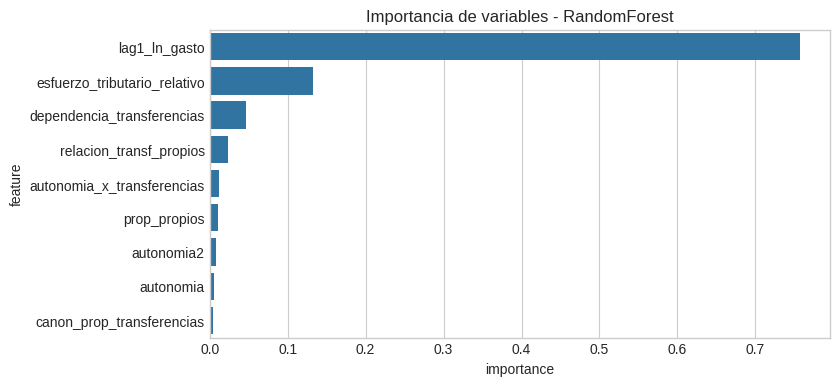

Importancia de variables - XGBoost


,feature,importance
8,lag1_ln_gasto,0.5432
4,esfuerzo_tributario_relativo,0.1875
7,relacion_transf_propios,0.1446
3,dependencia_transferencias,0.1013
0,autonomia,0.0198
2,autonomia_x_transferencias,0.0037
1,autonomia2,0.0000
6,prop_propios,0.0000
5,canon_prop_transferencias,0.0000


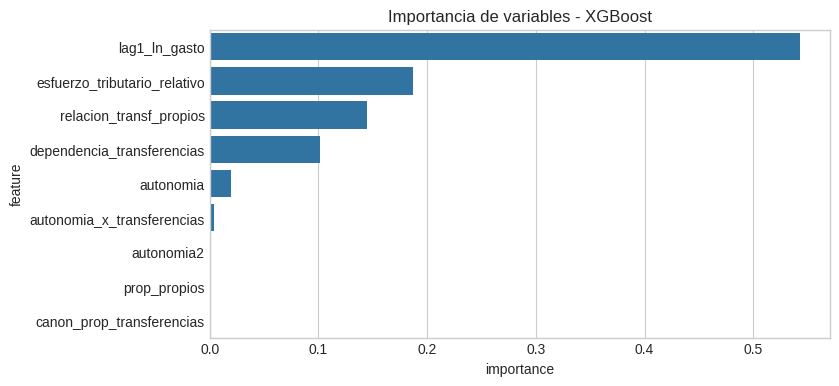

In [ ]:
# ======================
# Importancia de variables (RF/XGB)
# ======================
# Si el mejor modelo es RF o XGB, mostramos su importancia; además mostramos de RF y XGB en general.
for mname in ["RandomForest","XGBoost"]:
    m = models[mname]
    # Refit en todo X
    try:
        m.fit(X, y)
        if hasattr(m, "feature_importances_"):
            importances = m.feature_importances_
            fi = pd.DataFrame({"feature": features, "importance": importances}).sort_values("importance", ascending=False)
            print(f"Importancia de variables - {mname}")
            display(fi)
            plt.figure(figsize=(8,4))
            sns.barplot(x="importance", y="feature", data=fi)
            plt.title(f"Importancia de variables - {mname}")
            plt.show()
    except Exception as e:
        print(f"No se pudo obtener importancias para {mname}: {e}")

* La tabla y el gráfico de importancia de variables del modelo Random Forest muestran claramente que la variable más determinante en la predicción del gasto social es el rezago del gasto social (lag1_ln_gasto), con una importancia superior al 75%. Este hallazgo confirma la fuerte persistencia temporal del gasto social: la mejor predicción del gasto actual es el gasto del mes anterior, lo cual concuerda con el comportamiento típico del presupuesto público, donde la ejecución responde a inercia administrativa, continuidad de programas y ciclos de gasto. A continuación, destaca el esfuerzo tributario relativo, lo que indica que los municipios que recaudan más por sí mismos tienden a mantener patrones más estables y elevados de gasto social. La dependencia de transferencias también aporta al modelo, aunque en menor magnitud, mostrando que los niveles de financiamiento provenientes del gobierno central sí influyen, pero no al mismo grado que la dinámica temporal o la capacidad tributaria propia. Variables como autonomía, proporción del canon o ingresos propios tienen pesos mucho menores, lo que sugiere que su contribución al gasto social agregado es más moderada o se refleja indirectamente a través de otras variables. En síntesis, el Random Forest revela que el gasto social depende fundamentalmente de su propia historia y, en segundo lugar, de la estructura fiscal vinculada a la recaudación y las transferencias.

* La importancia de variables en el modelo XGBoost revela un patrón similar, aunque con una distribución ligeramente más balanceada que en el Random Forest. Nuevamente, el rezago del gasto social aparece como la variable dominante, explicando más de la mitad de la variabilidad del modelo (alrededor de 54%). Esto refuerza la conclusión de que la dinámica del gasto social está fuertemente condicionada por su comportamiento previo. A diferencia del Random Forest, en XGBoost el esfuerzo tributario relativo y la relación transferencias–ingresos propios adquieren una mayor relevancia, lo que sugiere que este modelo capta más explícitamente las diferencias en la estructura fiscal entre municipios. Asimismo, la dependencia de transferencias también contribuye de manera significativa, lo que es consistente con el rol que tienen las transferencias del gobierno central como principal fuente de financiamiento del gasto social. Variables como autonomía, el canon o las interacciones presentan importancia marginal, indicando que su capacidad explicativa es baja en el agregado mensual. XGBoost confirma que el gasto social es un proceso con fuerte inercia temporal, pero también sensible en menor grado a las diferencias fiscales estructurales relacionadas con la recaudación propia y el tipo de financiamiento que reciben los municipios.

---

## Conclusiones:

* El análisis realizado permite concluir que el gasto social municipal presenta una fuerte persistencia temporal, siendo el valor del mes previo el predictor más importante en todos los modelos. Esto confirma que la dinámica del gasto público está fuertemente influenciada por inercias administrativas, ciclos presupuestales y continuidad programática. En cuanto a las variables fiscales, destaca el rol del esfuerzo tributario relativo y la dependencia de transferencias, que aportan información relevante sobre la capacidad de financiamiento de los municipios y explican parte de la variabilidad del gasto social agregado. Las variables de autonomía fiscal y composición de ingresos tienen una contribución más moderada, lo que sugiere que, si bien son importantes para entender las diferencias entre municipios, su impacto en la serie promedio es más limitado.

* En términos de desempeño predictivo, el Random Forest se consolidó como el modelo más efectivo, logrando capturar relaciones no lineales y ofreciendo el MSE más bajo entre todas las alternativas evaluadas. Los modelos lineales penalizados (Ridge y Lasso) ofrecieron interpretaciones coherentes, aunque con menor capacidad predictiva, mientras que XGBoost mostró un desempeño inferior debido a la limitada longitud y complejidad de la serie temporal agregada. En conjunto, los resultados evidencian que la estructura fiscal influye en el gasto social, pero que la mayor parte del comportamiento se explica por la trayectoria histórica del mismo. Esto resalta la importancia de fortalecer la capacidad de ejecución y continuidad presupuestal como factores clave para comprender y predecir la evolución del gasto social municipal.